#PCD ASSIGNMENT 02
##IMAGE ENHANCEMENT
##MUSVI AULIA RAHARJO (25/559633/PA/23546)

##Image yang ada di kode ini hanya sebagai testing untuk berbagai metode (BEDA-BEDA TIAP METODE)


In [278]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

Saving SIDIK JARI.jpeg to SIDIK JARI.jpeg
Nama file : SIDIK JARI.jpeg
Ukuran gambar : (183, 275)
Nilai minimum : 0
Nilai maksimum : 255


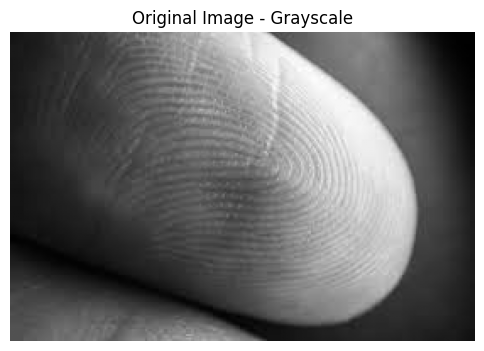

In [279]:
uploaded = files.upload()

filename = list(uploaded.keys())[0]

image = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

if image is None:

    print("Gambar gagal dibaca.")

else:

    print("Nama file :", filename)

    print("Ukuran gambar :", image.shape)

    print("Nilai minimum :", image.min())

    print("Nilai maksimum :", image.max())

    plt.figure(figsize=(6,6))

    plt.imshow(image, cmap="gray", vmin=0, vmax=255)

    plt.title("Original Image - Grayscale")

    plt.axis("off")

    plt.show()


##PIXEL-BASED / GRAY-LEVEL TRANSFORMATION

##Image Negative

In [138]:
negative = 255 - image

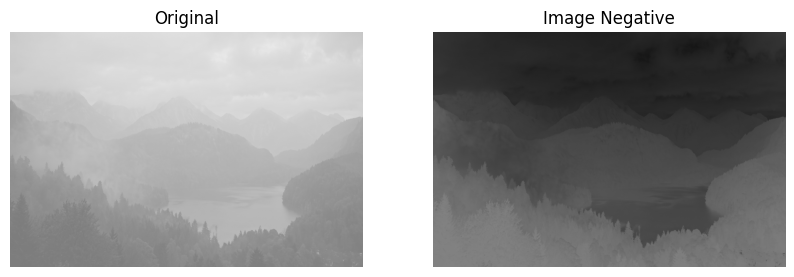

In [139]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image, cmap="gray", vmin=0, vmax=255)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(negative, cmap="gray", vmin=0, vmax=255)
plt.title("Image Negative")
plt.axis("off")

plt.show()


##Logarithmic Transformation

In [233]:
r = image.astype(np.float64) / 255.0

c = 7.0

log_image = c * np.log(1 + r)

log_image = (log_image / np.log(1 + c)) * 255

log_image = np.clip(log_image, 0, 255).astype(np.uint8)

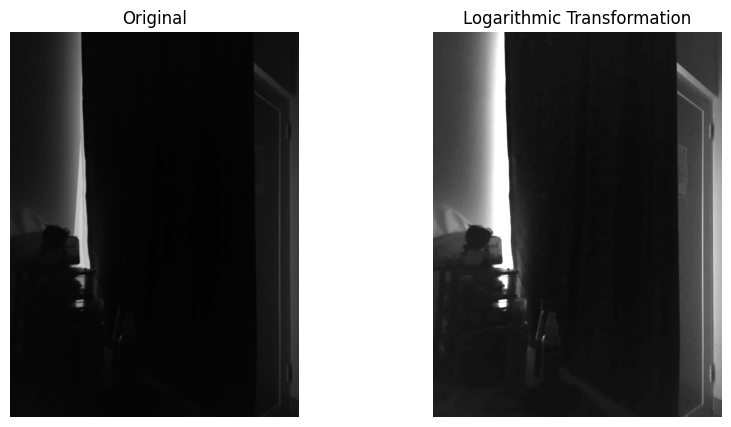

In [234]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image, cmap="gray", vmin=0, vmax=255)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(log_image, cmap="gray", vmin=0, vmax=255)
plt.title("Logarithmic Transformation")
plt.axis("off")

plt.show()


##Power-Law / Gamma Transformation

In [219]:
r = image.astype(np.float64) / 255.0

gamma_03 = 255 * (r ** 3)
gamma_05 = 255 * (r ** 5)
gamma_07 = 255 * (r ** 7)

gamma_03 = np.clip(gamma_03, 0, 255).astype(np.uint8)
gamma_05 = np.clip(gamma_05, 0, 255).astype(np.uint8)
gamma_07 = np.clip(gamma_07, 0, 255).astype(np.uint8)

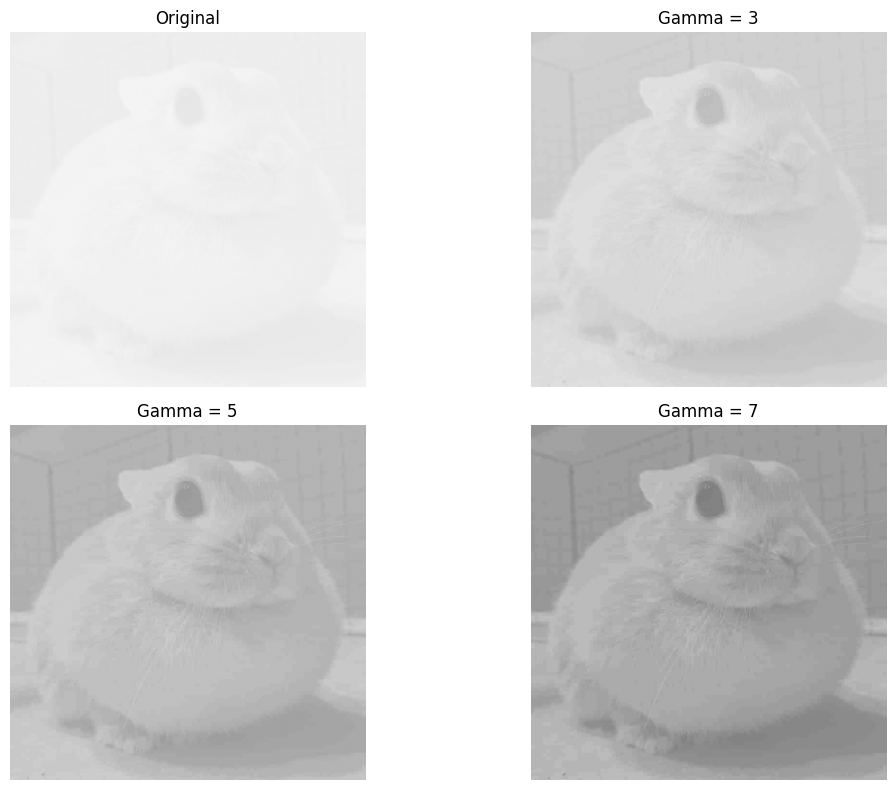

In [220]:
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(image, cmap="gray", vmin=0, vmax=255)
plt.title("Original")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(gamma_03, cmap="gray", vmin=0, vmax=255)
plt.title("Gamma = 3")
plt.axis("off")

plt.subplot(2,2,3)
plt.imshow(gamma_05, cmap="gray", vmin=0, vmax=255)
plt.title("Gamma = 5")
plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(gamma_07, cmap="gray", vmin=0, vmax=255)
plt.title("Gamma = 7")
plt.axis("off")

plt.tight_layout()
plt.show()

##Contrast Stretching

In [144]:
r_min = image.min()
r_max = image.max()

if r_max > r_min:

    contrast_stretch =((image.astype(np.float64) - r_min) / (r_max - r_min))*255

else:

    contrast_stretch = image.copy()

contrast_stretch = np.clip(contrast_stretch, 0, 255).astype(np.uint8)

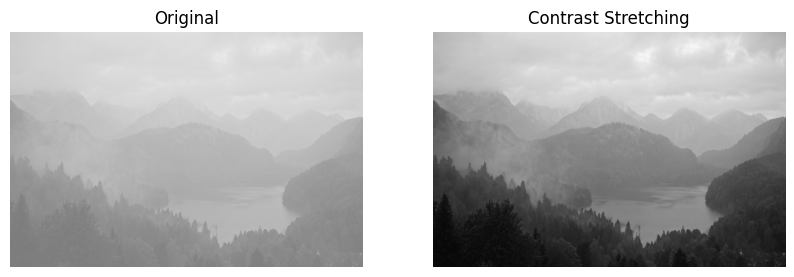

In [145]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image, cmap="gray", vmin=0, vmax=255)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(contrast_stretch, cmap="gray", vmin=0, vmax=255)
plt.title("Contrast Stretching")
plt.axis("off")

plt.show()


##Gray-Level Slicing

In [257]:
lower = 100
upper = 180

gray_slicing = np.zeros_like(image)

gray_slicing[(image >= lower) & (image <= upper)] = 255

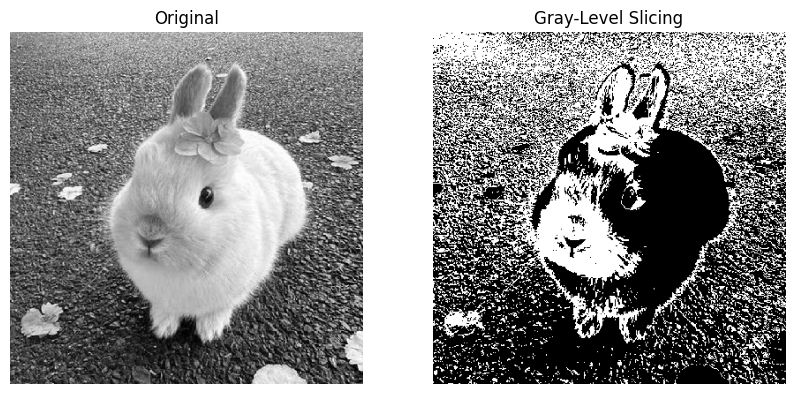

In [258]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image, cmap="gray", vmin=0, vmax=255)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(gray_slicing, cmap="gray", vmin=0, vmax=255)
plt.title("Gray-Level Slicing")
plt.axis("off")

plt.show()

##Bit-Plane Slicing

In [259]:
bit_planes = []

for bit in range(8):

    plane = ((image >> bit) & 1) * 255

    bit_planes.append(plane.astype(np.uint8))

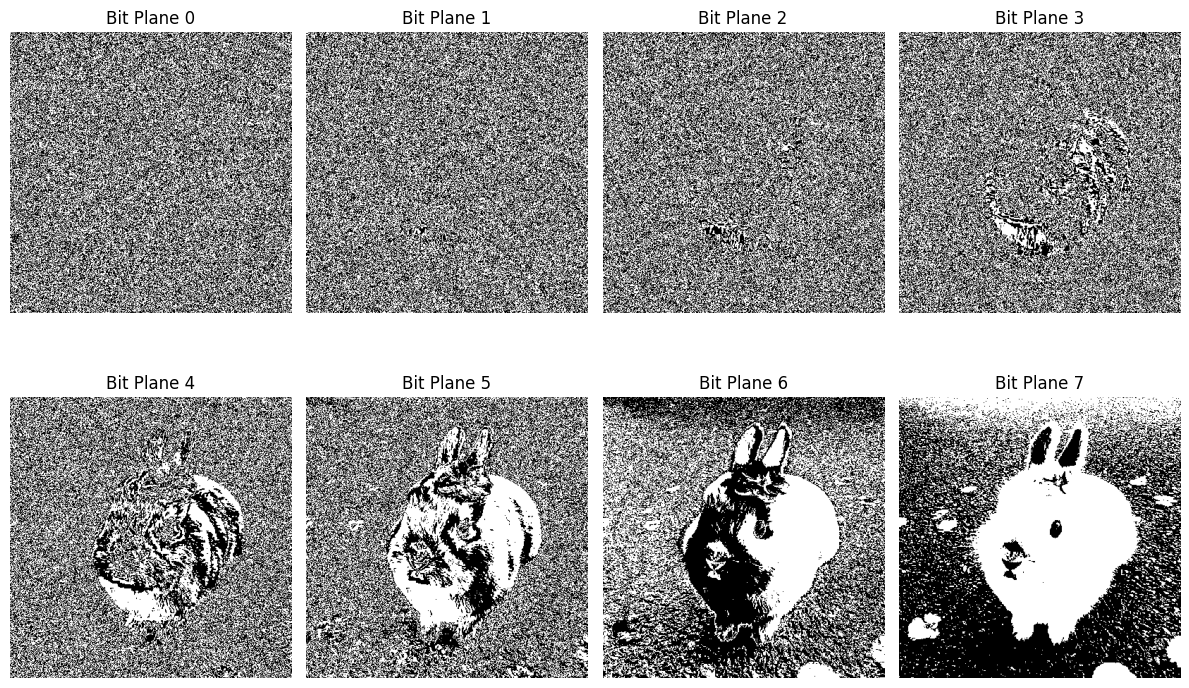

In [260]:
plt.figure(figsize=(12,8))

for i in range(8):

    plt.subplot(2,4,i+1)
    plt.imshow(bit_planes[i], cmap="gray", vmin=0, vmax=255)
    plt.title(f"Bit Plane {i}")
    plt.axis("off")

plt.tight_layout()
plt.show()

##HISTOGRAM PROCESSING

##Histogram Original

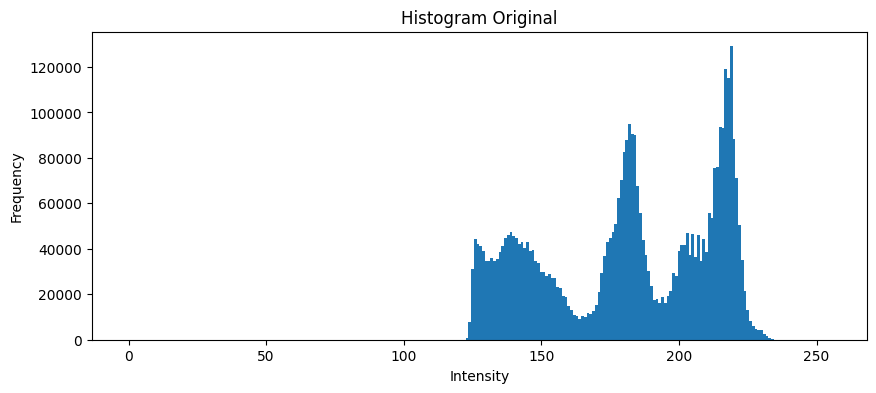

In [150]:
histogram = np.bincount(image.flatten(), minlength=256)

plt.figure(figsize=(10,4))

plt.bar(range(256), histogram, width=1)

plt.title("Histogram Original")
plt.xlabel("Intensity")
plt.ylabel("Frequency")

plt.show()

##Histogram Equalization

In [151]:
total_pixels = image.size

pdf = histogram / total_pixels

cdf = np.cumsum(pdf)

cdf_min = cdf[histogram > 0].min()

if cdf_min < 1:

    lookup_table = np.round(((cdf - cdf_min) / (1 - cdf_min)) * 255).astype(np.uint8)

else:

    lookup_table = np.arange(256, dtype=np.uint8)

In [152]:
equalized = lookup_table[image]

In [153]:
equalized_histogram = np.bincount(equalized.flatten(), minlength=256)

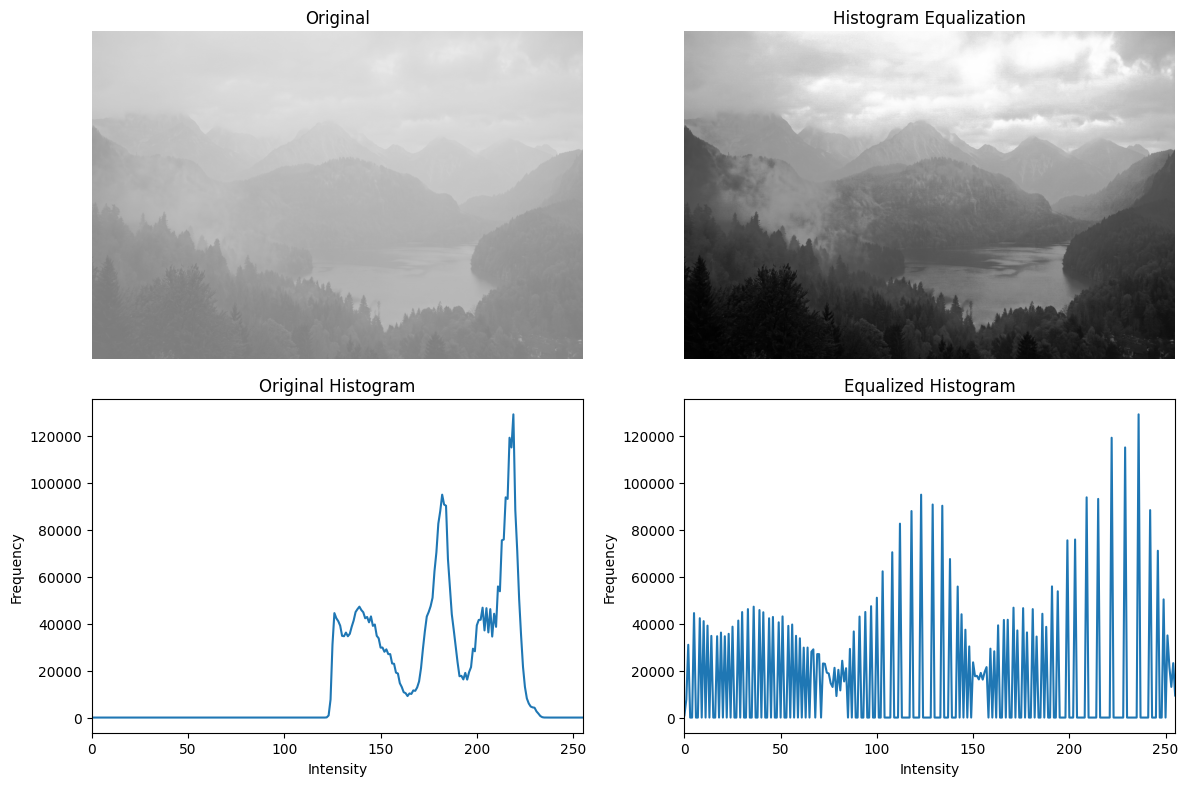

In [154]:
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(image, cmap="gray", vmin=0, vmax=255)
plt.title("Original")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(equalized, cmap="gray", vmin=0, vmax=255)
plt.title("Histogram Equalization")
plt.axis("off")

plt.subplot(2,2,3)
plt.plot(histogram)
plt.title("Original Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.xlim(0,255)

plt.subplot(2,2,4)
plt.plot(equalized_histogram)
plt.title("Equalized Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.xlim(0,255)

plt.tight_layout()
plt.show()

##Histogram Specification

In [155]:
x = np.arange(256)

target_pdf = np.exp(-0.5 * ((x - 128) / 40) ** 2)

target_pdf = target_pdf / target_pdf.sum()

target_cdf = np.cumsum(target_pdf)

source_cdf = np.cumsum(histogram / image.size)


In [156]:
mapping = np.zeros(256, dtype=np.uint8)

for i in range(256):

    difference = np.abs(target_cdf - source_cdf[i])

    mapping[i] = np.argmin(difference)

In [157]:
specified = mapping[image]
specified_histogram = np.bincount(specified.flatten(), minlength=256)

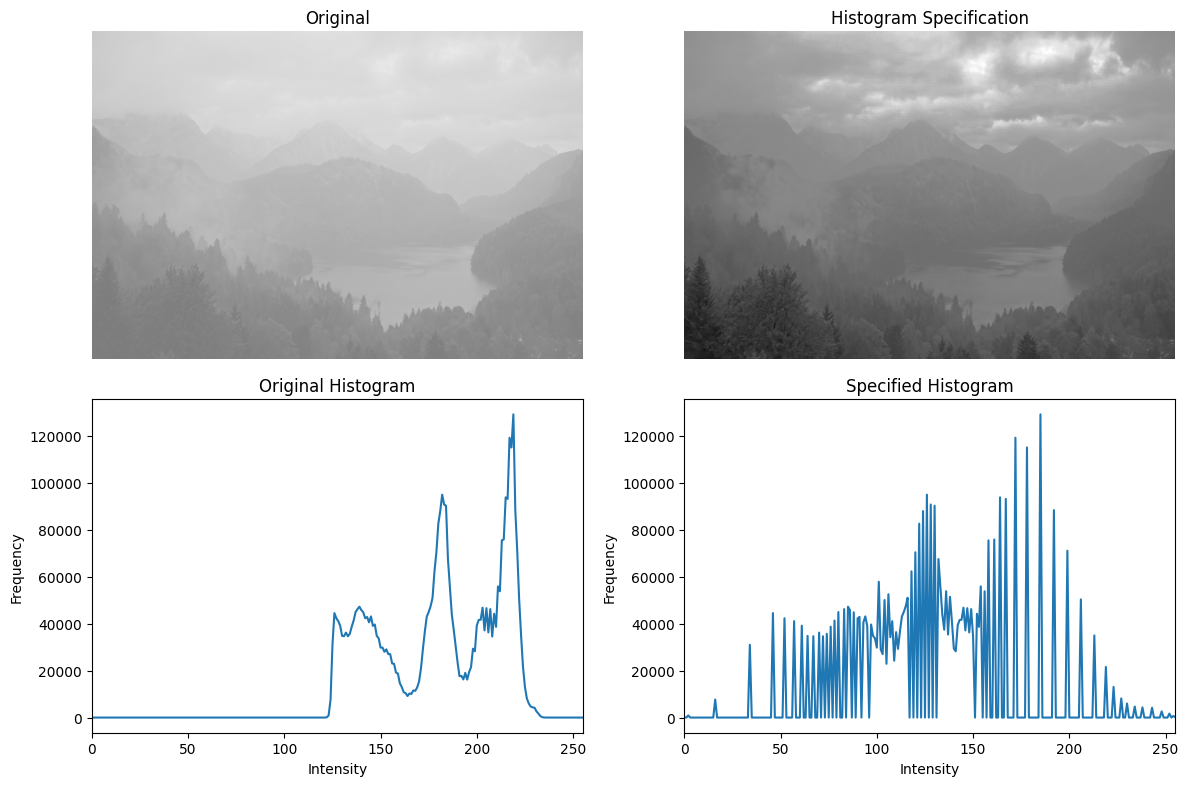

In [158]:
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(image, cmap="gray", vmin=0, vmax=255)
plt.title("Original")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(specified, cmap="gray", vmin=0, vmax=255)
plt.title("Histogram Specification")
plt.axis("off")

plt.subplot(2,2,3)
plt.plot(histogram)
plt.title("Original Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.xlim(0,255)

plt.subplot(2,2,4)
plt.plot(specified_histogram)
plt.title("Specified Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.xlim(0,255)

plt.tight_layout()
plt.show()

##SPATIAL FILTERING

##Convolution

In [237]:
def convolution(image, kernel):

    kernel_height, kernel_width = kernel.shape

    pad_height = kernel_height // 2
    pad_width = kernel_width // 2

    padded = np.pad(image, ((pad_height, pad_height), (pad_width, pad_width)), mode="edge")

    result = np.zeros_like(image, dtype=np.float64)

    for i in range(image.shape[0]):

        for j in range(image.shape[1]):

            region = padded[i:i + kernel_height, j:j + kernel_width]

            result[i,j] = np.sum(region * kernel)

    return np.clip(result, 0, 255).astype(np.uint8)

##Mean Filter

In [263]:
mean_kernel = np.ones((3,3)) / 9

mean_filter = convolution(image, mean_kernel)

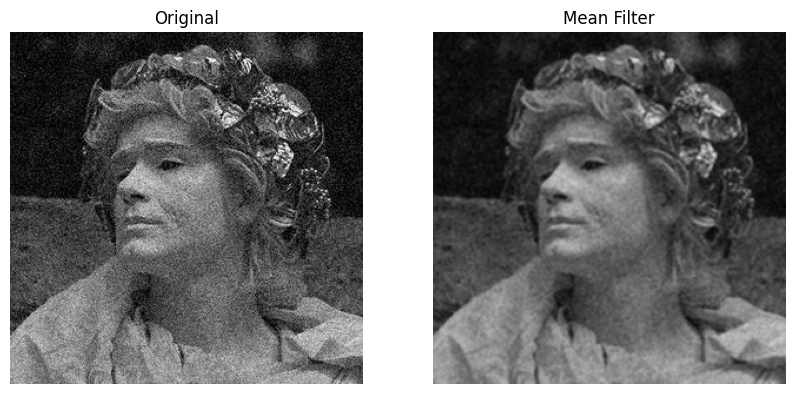

In [264]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image, cmap="gray", vmin=0, vmax=255)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mean_filter, cmap="gray", vmin=0, vmax=255)
plt.title("Mean Filter")
plt.axis("off")

plt.show()


##Gaussian Filter

In [266]:
sigma = 1.0

x, y = np.meshgrid(np.arange(-1,2), np.arange(-1,2))

gaussian_kernel = (1 / (2 * np.pi * sigma**2)) * np.exp(-(x**2 + y**2) / (2 * sigma**2))

gaussian_kernel = gaussian_kernel / gaussian_kernel.sum()

print(gaussian_kernel)

[[0.07511361 0.1238414  0.07511361]
 [0.1238414  0.20417996 0.1238414 ]
 [0.07511361 0.1238414  0.07511361]]


In [267]:
gaussian_filter = convolution(image, gaussian_kernel)

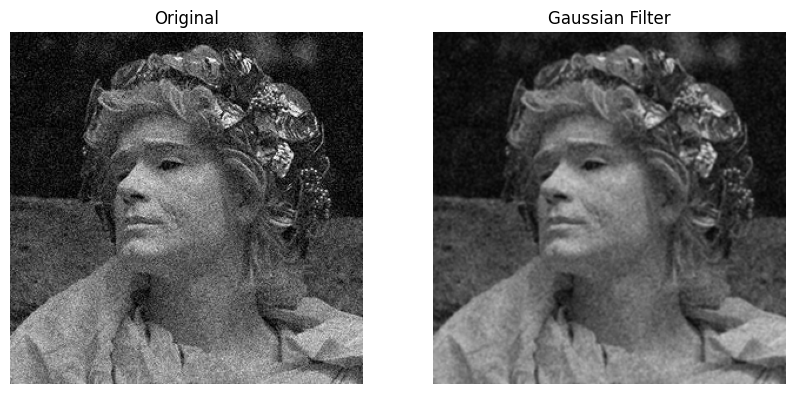

In [268]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image, cmap="gray", vmin=0, vmax=255)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(gaussian_filter, cmap="gray", vmin=0, vmax=255)
plt.title("Gaussian Filter")
plt.axis("off")

plt.show()

##Sharpening Filter

In [271]:
sharpen_kernel = np.array([
    [0, -1,  0],
    [-1, 5, -1],
    [0, -1,  0]
])

sharpened = convolution(image, sharpen_kernel)


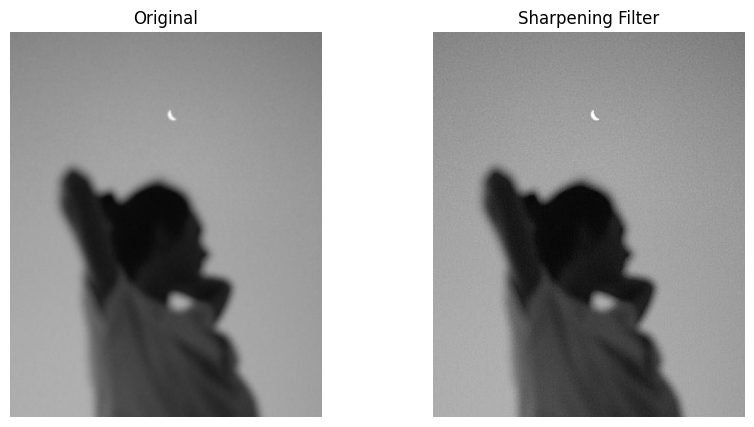

In [272]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image, cmap="gray", vmin=0, vmax=255)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(sharpened, cmap="gray", vmin=0, vmax=255)
plt.title("Sharpening Filter")
plt.axis("off")

plt.show()


##Laplacian Filter

In [286]:
laplacian_kernel = np.array([
    [0,  1, 0],
    [1, -4, 1],
    [0,  1, 0]
])

laplacian = convolution(image, laplacian_kernel)


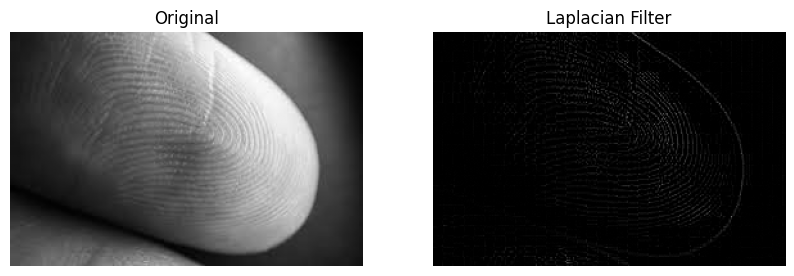

In [287]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image, cmap="gray", vmin=0, vmax=255)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(laplacian, cmap="gray", vmin=0, vmax=255)
plt.title("Laplacian Filter")
plt.axis("off")

plt.show()

##Median Filter

In [253]:
def median_filter(image, kernel_size=3):

    pad = kernel_size // 2

    padded = np.pad(image, ((pad, pad), (pad, pad)), mode="edge")

    result = np.zeros_like(image)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):

            region = padded[i:i+kernel_size, j:j+kernel_size]

            result[i,j] = np.median(region)

    return result

In [254]:
median = median_filter(image, 3)


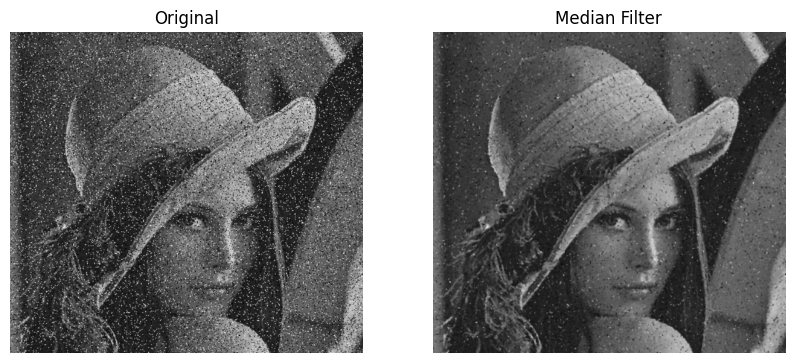

In [252]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image, cmap="gray", vmin=0, vmax=255)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(median, cmap="gray", vmin=0, vmax=255)
plt.title("Median Filter")
plt.axis("off")

plt.show()
